In [ ]:
%load_ext autoreload
%autoreload 2

In [42]:
import os
import re
import sys
import shutil
import zipfile
import requests
from urllib.parse import urlparse, parse_qs
from tqdm import tqdm
from urllib.parse import urlparse, parse_qs
from tqdm.notebook import tqdm
sys.path.append(r'E:\repository\dataset_tools\isds_tool\PS_data')
from vis import yolo_to_mot, esresult2yolo_track, esimage_merge, rename_yolo_files, select_topk_timestamp_files
from img_preprocess import select_img
from deduplication_demo import filter_deduplication

In [ ]:
root_dir = r"Y:\ZHL\isds\PS"
RESULT_ALL = "http://ec2-54-46-0-164.ap-east-1.compute.amazonaws.com/emes/api/v2/workflow-result/exportResults?subProjectId="
RESULT_JSON = "http://ec2-54-46-0-164.ap-east-1.compute.amazonaws.com/emes/api/v2/workflow-result/exportOutputResults?subProjectId="
CONFIG_EXPORT = "http://ec2-54-46-0-164.ap-east-1.compute.amazonaws.com/emes/api/v2/getSubprojectMetaData?subProjectId="
anno_dir = r'E:\data\202502_signboard\data_annotation\ps_data\task\merge_dir_0811'


subproject_list = [
    # 301, 303, 304, 310, 306, 308, 309
    # 342, 343, 344, 345, 346, 347, 348, 349, 350, 352, 353, 354, 355, 356, 358, 359, 360, 361, 363, 363, 364, 365, 366, 367, 368 
    369, 370
]

merge_dir = r'Y:\ZHL\isds\PS\results\task_0811'

In [ ]:
# def extract_date_from_project_name(project_name):
#     pattern = r"^2025(\d{4})_SIT$"
#     match = re.match(pattern, project_name)
    
#     if match:
#         date = match.group(1)  # 提取 xxxx
#         return date
#     else:
#         return 0000

def extract_date_from_project_name(project_name):
    pattern = r"^2025(\d{4})_UAT$"
    match = re.match(pattern, project_name)
    
    if match:
        date = match.group(1)  # 提取 xxxx
        return date
    else:
        return 0000

In [ ]:
import concurrent.futures
from concurrent.futures import ThreadPoolExecutor

# 多线程下载函数
def download_zip_files_mp(subproject_list, root_dir, overwirte=False, max_workers=4):
    zip_download_dict = {}

    def download_single(subproject_id):
        # 每个线程创建独立的session
        session = requests.Session()
        session.headers.update({
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
        })

        download_url = RESULT_ALL+str(subproject_id)
        config_url = CONFIG_EXPORT+str(subproject_id)

        try:
            print(f"🔗 正在连接: {config_url}")
            response = session.get(config_url)
            response.raise_for_status()
            data = response.json()
            project_name = data['project']['name']
            date = extract_date_from_project_name(project_name)

            save_dir = os.path.join(root_dir, 'task'+date, 'results')
            os.makedirs(save_dir, exist_ok=True)

            print(f"🔗 正在连接: {download_url}")
            response = session.get(download_url, stream=True)
            response.raise_for_status()

            total_size = int(response.headers.get("content-length", 0))
            chunk_size = 1024 * 1024  # 1MB

            print(f'total size: {total_size/chunk_size} MB')

            parsed_url = urlparse(download_url)
            query_params = parse_qs(parsed_url.query)
            sub_project_id = query_params.get('subProjectId', ['unknown'])[0]
            filename = f"{sub_project_id}.zip"
            save_path = os.path.join(save_dir, filename)

            if not os.path.exists(save_path) or overwirte:
                with open(save_path, 'wb') as f, tqdm(
                    total=total_size,
                    unit='B',
                    unit_scale=True,
                    unit_divisor=1024,
                    desc=f"📥 下载 {filename} -> {save_dir}",
                    leave=True,
                ) as pbar:
                    for chunk in response.iter_content(chunk_size=chunk_size):
                        if chunk:
                            f.write(chunk)
                            pbar.update(len(chunk))

                print(f"✅ 下载完成: {save_path}\n")
                return subproject_id, save_path
            else:
                print(f"⚠️ 文件已存在，跳过下载: {save_path}\n")
                return subproject_id, save_path
        except Exception as e:
            print(f"❌ 下载失败: {download_url}\n原因: {e}")
            return subproject_id, None

    # 使用线程池执行下载任务
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        # 提交所有任务
        futures = {executor.submit(download_single, sid): sid for sid in subproject_list}

        # 收集结果
        for future in concurrent.futures.as_completed(futures):
            subproject_id, save_path = future.result()
            if save_path:
                zip_download_dict[subproject_id] = save_path

    return zip_download_dict

In [ ]:
# zip_download_dict = download_zip_files(subproject_list, root_dir)
zip_download_dict = download_zip_files_mp(subproject_list, root_dir)

In [ ]:
def simple_unzip(zip_path, dst_dir):
    print(f'{zip_path} unzip...')
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dst_dir)
    print(f'{zip_path} done\n')

In [ ]:
for key, zip_path in zip_download_dict.items():
    simple_unzip(zip_path, dst_dir=zip_path.replace('.zip', ''))


In [ ]:
for key, zip_path in zip_download_dict.items():
    esimage_merge(zip_path.replace('.zip', ''))

In [ ]:
for key, zip_path in zip_download_dict.items():
    esresult2yolo_track(zip_path.replace('.zip', ''))

In [45]:
for key, zip_path in zip_download_dict.items():
    yolo_dir = os.path.join(zip_path.replace('.zip', ''), 'yolo_dataset')
    select_yolo_dir = yolo_dir + '_select'
    select_topk_timestamp_files(yolo_dir, select_yolo_dir)

处理时间戳 20250812145721700: 100%|██████████| 6/6 [00:00<00:00, 13.24it/s]


选择完成: 共处理30个文件，来自5个时间戳，已保存到Y:\ZHL\isds\PS\task0812\results\370\yolo_dataset_select
选中的时间戳: ['20250812145555099', '20250812145558400', '20250812145603800', '20250812145720400', '20250812145721700']


处理时间戳 20250812140354599: 100%|██████████| 6/6 [00:00<00:00, 15.66it/s]

选择完成: 共处理30个文件，来自5个时间戳，已保存到Y:\ZHL\isds\PS\task0812\results\369\yolo_dataset_select
选中的时间戳: ['20250812140329800', '20250812140349600', '20250812140352300', '20250812140353400', '20250812140354599']


In [48]:
for key, zip_path in zip_download_dict.items():
    yolo_dir = os.path.join(zip_path.replace('.zip', ''), 'yolo_dataset_select')
    rename_yolo_dir = yolo_dir + '_rename'
    rename_yolo_files(yolo_dir, rename_yolo_dir)

100%|██████████| 30/30 [00:01<00:00, 16.45it/s]


自动生成的前缀映射: {'DA4930148': 1, 'DA5148680': 2, 'DA5148683': 3, 'DA5324645': 4, 'DA5324655': 5, 'DA6102933': 6}
重命名完成: 共处理30个文件，已保存到Y:\ZHL\isds\PS\task0812\results\370\yolo_dataset_select_rename


100%|██████████| 30/30 [00:01<00:00, 16.28it/s]

自动生成的前缀映射: {'DA4930148': 1, 'DA5148680': 2, 'DA5148683': 3, 'DA5324645': 4, 'DA5324655': 5, 'DA6102933': 6}
重命名完成: 共处理30个文件，已保存到Y:\ZHL\isds\PS\task0812\results\369\yolo_dataset_select_rename


In [49]:
for key, zip_path in zip_download_dict.items():
    yolo_dir = os.path.join(zip_path.replace('.zip', ''), 'yolo_dataset_select_rename')
    yolo_to_mot(yolo_dir, os.path.join(yolo_dir, 'mot_gt.csv'))

100%|██████████| 30/30 [00:00<00:00, 91.95it/s] 


In [89]:
import numpy as np
import pandas as pd
import motmetrics as mm
import warnings

def evaluate_mot(gt_file, pred_file, iou_threshold=0.5, target_class=None):
    """
    计算 MOT 指标（MOTA, IDF1, FP, FN, ID switches 等）
    gt_file/pred_file: 支持逗号或空格分隔的 MOT 风格文件
    iou_threshold: IoU 匹配阈值（如 0.5）
    target_class: 若你的数据里有 'class' 列且只评估某类（如 1），可传入该类ID
    """
    # 更稳的读取方式：兼容逗号/空格


    print(f'{os.path.exists(gt_file), gt_file}')
    print(f'{os.path.exists(pred_file), pred_file}')
    gt = pd.read_csv(gt_file, header=None, 
                    names=['frame', 'id', 'x', 'y', 'w', 'h', 'conf', 'class', 'visibility'])
    pred = pd.read_csv(pred_file, header=None,
                        names=['frame', 'id', 'x', 'y', 'w', 'h', 'conf', 'class', 'visibility'])

    # 只保留真正有用的列
    keep_cols = ['frame','id','x','y','w','h','conf','class','visibility']
    gt = gt[keep_cols].copy()
    pred = pred[keep_cols].copy()

    # 类型清洗
    for df in (gt, pred):
        for k in ['frame','id']:
            df[k] = pd.to_numeric(df[k], errors='coerce').astype('Int64')
        for k in ['x','y','w','h','conf','class','visibility']:
            df[k] = pd.to_numeric(df[k], errors='coerce')

    # 过滤无效行
    gt = gt.dropna(subset=['frame','id','x','y','w','h'])
    pred = pred.dropna(subset=['frame','id','x','y','w','h'])

    # 过滤 GT 忽略区域/非目标类
    # - id <= 0: 通常为 ignore / crowd，应剔除
    gt = gt[gt['id'] > 0]
    # - 若存在 conf 且 conf==0（或 -1）代表忽略，也剔除
    if 'conf' in gt.columns:
      gt = gt[gt['conf'].fillna(1) > 0]
    # - 若指定了目标类，只保留该类
    if target_class is not None and 'class' in gt.columns:
      gt = gt[gt['class'] == target_class]

    # 预测里常见的 class/visibility 不用于匹配，这里不强制过滤
    # 但若你的预测是多类检测，也可按需过滤：
    if target_class is not None and 'class' in pred.columns:
      pred = pred[(pred['class'].isna()) | (pred['class'] == target_class)]

    if gt.empty:
        warnings.warn("GT 为空，无法计算。")
        return None

    # 初始化评估器
    acc = mm.MOTAccumulator(auto_id=False)

    # 帧号并集，升序
    all_frames = sorted(set(gt['frame'].astype(int)).union(set(pred['frame'].astype(int))))

    for frame_id in all_frames:
        gt_objs = gt[gt['frame'] == frame_id]
        pred_objs = pred[pred['frame'] == frame_id]

        gt_ids = gt_objs['id'].astype(int).values if not gt_objs.empty else np.array([], dtype=int)
        pred_ids = pred_objs['id'].astype(int).values if not pred_objs.empty else np.array([], dtype=int)

        gt_bboxes = gt_objs[['x','y','w','h']].values if not gt_objs.empty else np.zeros((0,4), dtype=float)
        pred_bboxes = pred_objs[['x','y','w','h']].values if not pred_objs.empty else np.zeros((0,4), dtype=float)

        # 计算 IoU cost 矩阵（距离 = 1 - IoU；IoU < 阈值 的条目将被置为 NaN，不参与匹配）
        iou_cost = mm.distances.iou_matrix(gt_bboxes, pred_bboxes, max_iou=iou_threshold)

        acc.update(gt_ids, pred_ids, iou_cost, frameid=int(frame_id))

    # 计算指标：用 compute_many 得到 DataFrame，便于渲染
    mh = mm.metrics.create()
    metrics = [
        'num_frames', 'num_objects',
        'idf1', 'idp', 'idr',
        'recall', 'precision',
        'fp', 'fn', 'id_switches',
        'mota', 'motp',
        'mostly_tracked', 'mostly_lost'
    ]

    summary = mh.compute_many(
        [acc],
        metrics=metrics,
        names=['seq'],
        # 对 MT/ML 指标显式设置最小重叠阈值（与 IoU 阈值保持一致更直观）
        # 注意：motmetrics 的 MT/ML 是按时间上覆盖比例定义的，这里的 min_overlap 是匹配阈值
        min_overlap=iou_threshold
    )

    # 美化输出
    pct = ['idf1','idp','idr','recall','precision','mota']
    intcols = ['fp','fn','id_switches','num_frames','num_objects','mostly_tracked','mostly_lost']
    formatters = {m: '{:.2%}'.format for m in pct}
    formatters.update({m: '{:.0f}'.format for m in intcols})

    print("="*50)
    print("MOT 评估结果:")
    print(mm.io.render_summary(summary, formatters=formatters))
    print("="*50)

    return summary


In [90]:
evaluate_mot(
    r'Y:\ZHL\isds\PS\task0812\results\369\yolo_dataset_select_rename\mot_gt.csv',
    r'Y:\ZHL\isds\PS\task0812\results\369\yolo_dataset_select_rename\mot_pred.csv'

)

(True, 'Y:\\ZHL\\isds\\PS\\task0812\\results\\369\\yolo_dataset_select_rename\\mot_gt.csv')
(True, 'Y:\\ZHL\\isds\\PS\\task0812\\results\\369\\yolo_dataset_select_rename\\mot_pred.csv')


C:\Users\USER\AppData\Local\Temp\ipykernel_29604\3153918890.py:55: UserWarning: GT 为空，无法计算。
  warnings.warn("GT 为空，无法计算。")


In [85]:
import pandas as pd
import numpy as np

COLS = ['frame','id','x','y','w','h','conf','class','visibility']

def load_mot(file_path):
    # 1) 读：兼容逗号/空格、BOM/GBK
    print(os.path.exists(file_path))
    df = pd.read_csv(file_path, header=None, names=COLS,)

    # 2) 基础自检
    print('预览:'); print(df.head(3))
    print('形状:', df.shape)

    # 3) 仅在必要列上做数值化；保留原始字符串避免误伤
    for k in ['frame','id','x','y','w','h']:
        df[k] = pd.to_numeric(df[k], errors='coerce')

    # 4) 丢掉关键几列缺失的行
    before = len(df)
    df = df.dropna(subset=['frame','id','x','y','w','h'])
    print(f'dropna 关键列：{before} -> {len(df)}')

    # 5) 可选：把极长时间戳映射为连续帧号（强烈建议）
    #       这样 motmetrics 的帧逻辑最稳
    uniq_frames = pd.Index(df['frame'].astype(np.int64).unique())
    frame_map = {f:i+1 for i,f in enumerate(sorted(uniq_frames))}
    df['frame'] = df['frame'].astype(np.int64).map(frame_map)

    # 6) 不做任何 class/conf 过滤，留到评估前再决定
    return df


In [88]:
gt_file = r'Y:\ZHL\isds\PS\task0812\results\369\yolo_dataset_select_rename\mot_gt.csv'
pred_file = r'Y:\ZHL\isds\PS\task0812\results\369\yolo_dataset_select_rename\mot_pred.csv'
gt = load_mot(gt_file)   # 看控制台“预览/形状/dropna前后”是否合理
pred = load_mot(pred_file)
print('GT空吗？', gt.empty, 'Pred空吗？', pred.empty)

True
预览:
                frame      id     x     y    w    h  conf  class  visibility
0  120250812140329800  336112  3143  1471  697  324     0      6           1
1  120250812140329800  336113   347  1011  205  905     0      6           1
2  120250812140329800  336114  4001   921   93  523     0      6           1
形状: (95, 9)
dropna 关键列：95 -> 95
True
预览:
                frame      id       x       y      w      h  conf  class  \
0  120250812140329800  336112  3143.4  1471.3  697.9  324.5     1      6   
1  120250812140329800  336113   347.9  1011.2  205.7  905.2     1      6   
2  120250812140329800  336114  4001.9   921.9   93.2  523.7     1      6   

   visibility  
0           1  
1           1  
2           1  
形状: (93, 9)
dropna 关键列：93 -> 93
GT空吗？ False Pred空吗？ False


In [98]:
import os
import numpy as np
import pandas as pd
import motmetrics as mm

COLS = ['frame','id','x','y','w','h','conf','class','visibility']

def read_mot_like(path):
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    df = pd.read_csv(
        path, header=None, names=COLS,
        sep=r'[,\s]+', engine='python',
        encoding='utf-8-sig', comment='#', skip_blank_lines=True
    )
    # 关键列转数值
    for k in ['frame','id','x','y','w','h','conf','class','visibility']:
        if k in df.columns:
            df[k] = pd.to_numeric(df[k], errors='coerce')
    df = df.dropna(subset=['frame','id','x','y','w','h'])
    if len(df) == 0:
        raise ValueError(f'{path} 清洗后为空')
    df['frame'] = df['frame'].astype(np.int64)
    df['id']    = df['id'].astype(np.int64)
    return df.sort_values(['frame','id']).reset_index(drop=True)

def remap_frames_to_1based(df):
    uniq = np.sort(df['frame'].unique())
    mp = {f:i+1 for i,f in enumerate(uniq)}
    out = df.copy()
    out['frame'] = out['frame'].map(mp).astype(int)
    return out

def evaluate_mot(gt_file, pred_file, iou_threshold=0.5, target_class=None, pred_conf_thresh=None):
    gt = read_mot_like(gt_file)
    pred = read_mot_like(pred_file)

    # 忽略区
    gt = gt[gt['id'] > 0]

    # 可选：按类/置信度过滤
    if target_class is not None and 'class' in gt.columns:
        gt   = gt[(gt['class'].isna()) | (gt['class'] == target_class)]
        pred = pred[(pred['class'].isna()) | (pred['class'] == target_class)]
    if pred_conf_thresh is not None and 'conf' in pred.columns:
        pred = pred[pred['conf'].fillna(1.0) >= float(pred_conf_thresh)]

    # 将任意帧编号映射为 1..N（解决时间戳/大整数问题）
    gt   = remap_frames_to_1based(gt)
    pred = remap_frames_to_1based(pred)

    acc = mm.MOTAccumulator(auto_id=False)
    all_frames = sorted(set(gt['frame']).union(set(pred['frame'])))

    for f in all_frames:
        gtf   = gt[gt['frame'] == f]
        predf = pred[pred['frame'] == f]

        gt_ids  = gtf['id'].astype(int).to_numpy()
        pd_ids  = predf['id'].astype(int).to_numpy()
        gt_box  = gtf[['x','y','w','h']].to_numpy(dtype=float)
        pd_box  = predf[['x','y','w','h']].to_numpy(dtype=float)

        # IoU < 阈值 的位置被置 NaN，不参与匹配
        iou_cost = mm.distances.iou_matrix(gt_box, pd_box, max_iou=iou_threshold)
        acc.update(gt_ids, pd_ids, iou_cost, frameid=int(f))

    mh = mm.metrics.create()

    # 用版本自带的 MOTChallenge 指标集（兼容老版本），再补充 ID 指标
    metrics = list(mm.metrics.motchallenge_metrics)
    for m in ['idp', 'idr', 'idf1']:
        if m not in metrics:
            metrics.append(m)

    # 注意：老版本没有 min_overlap 参数
    summary = mh.compute_many(
        [acc],
        metrics=metrics,
        names=['seq']
    )

    # 动态选择可用列做格式化
    pct_names = [n for n in ['mota','motp','precision','recall','idf1','idp','idr'] if n in summary.columns]
    int_names = [n for n in [
        'num_frames','num_objects','num_predictions','num_matches',
        'num_false_positives','num_misses','num_switches',
        'mostly_tracked','mostly_lost'
    ] if n in summary.columns]

    formatters = {m: '{:.2%}'.format for m in pct_names}
    formatters.update({m: '{:.0f}'.format for m in int_names})

    print('='*60)
    print(f'MOT 评估（IoU≥{iou_threshold}）:')
    print(mm.io.render_summary(summary, formatters=formatters))
    print('='*60)

    return summary


In [99]:
gt_file = r'Y:\ZHL\isds\PS\task0812\results\369\yolo_dataset_select_rename\mot_gt.csv'
pred_file = r'Y:\ZHL\isds\PS\task0812\results\369\yolo_dataset_select_rename\mot_pred.csv'
evaluate_mot(gt_file, pred_file)

MOT 评估（IoU≥0.5）:
      idf1    idp    idr recall precision  num_unique_objects mostly_tracked  partially_tracked mostly_lost num_false_positives num_misses num_switches  num_fragmentations   mota  motp  num_transfer  num_ascend  num_migrate
seq 48.94% 49.46% 48.42% 97.89%   100.00%                  35             35                  0           0                   0          2           46                   2 49.47% 1.06%             7          39            1


,idf1,idp,idr,recall,precision,num_unique_objects,mostly_tracked,partially_tracked,mostly_lost,num_false_positives,num_misses,num_switches,num_fragmentations,mota,motp,num_transfer,num_ascend,num_migrate
seq,0.489362,0.494624,0.484211,0.978947,1.0,35,35,0,0,0,2,46,2,0.494737,0.010581,7,39,1


In [100]:
# 可视化：扫预测置信度阈值，画 IDF1 / MOTA / ID switches
import numpy as np
import matplotlib.pyplot as plt

def sweep_and_plot(gt_file, pred_file, thresholds=None, iou_threshold=0.5, target_class=None):
    if thresholds is None:
        thresholds = np.linspace(0.0, 0.9, 10)  # 0.0 ~ 0.9 共10点

    idf1_list, mota_list, ids_list = [], [], []

    for th in thresholds:
        summary = evaluate_mot(
            gt_file, pred_file,
            iou_threshold=iou_threshold,
            target_class=target_class,
            pred_conf_thresh=th
        )

        # 兼容不同 motmetrics 版本的列名
        def get_col(df, names, default=np.nan):
            for n in names:
                if n in df.columns:
                    return float(df.iloc[0][n])
            return default

        idf1 = get_col(summary, ['idf1'])
        mota = get_col(summary, ['mota'])
        ids  = get_col(summary, ['num_switches', 'id_switches'])  # 某些版本是 num_switches

        idf1_list.append(idf1 if not np.isnan(idf1) else 0.0)
        mota_list.append(mota if not np.isnan(mota) else 0.0)
        ids_list.append(ids if not np.isnan(ids) else 0.0)

    # 画图：左轴曲线（IDF1/MOTA），右轴柱状（ID switches）
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax2 = ax1.twinx()

    ax1.plot(thresholds, idf1_list, marker='o', label='IDF1')
    ax1.plot(thresholds, mota_list, marker='s', label='MOTA')
    ax2.bar(thresholds, ids_list, width=(thresholds[1]-thresholds[0])*0.6 if len(thresholds)>1 else 0.05,
            alpha=0.3, label='ID switches')

    ax1.set_xlabel('Prediction confidence threshold')
    ax1.set_ylabel('Score (IDF1 / MOTA)')
    ax2.set_ylabel('ID switches (count)')
    ax1.set_title(f'IDF1 vs MOTA vs ID switches (IoU≥{iou_threshold})')
    ax1.grid(True, linestyle='--', alpha=0.4)

    # 合并图例
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

    plt.tight_layout()
    plt.show()

# === 使用示例 ===
# gt_path   = r'path\to\mot_gt.csv'
# pred_path = r'path\to\mot_pred.csv'
# sweep_and_plot(gt_path, pred_path, thresholds=np.linspace(0, 0.9, 10), iou_threshold=0.5, target_class=None)


MOT 评估（IoU≥0.5）:
      idf1    idp    idr recall precision  num_unique_objects mostly_tracked  partially_tracked mostly_lost num_false_positives num_misses num_switches  num_fragmentations   mota  motp  num_transfer  num_ascend  num_migrate
seq 48.94% 49.46% 48.42% 97.89%   100.00%                  35             35                  0           0                   0          2           46                   2 49.47% 1.06%             7          39            1
MOT 评估（IoU≥0.5）:
      idf1    idp    idr recall precision  num_unique_objects mostly_tracked  partially_tracked mostly_lost num_false_positives num_misses num_switches  num_fragmentations   mota  motp  num_transfer  num_ascend  num_migrate
seq 48.94% 49.46% 48.42% 97.89%   100.00%                  35             35                  0           0                   0          2           46                   2 49.47% 1.06%             7          39            1
MOT 评估（IoU≥0.5）:
      idf1    idp    idr recall precision  num_unique

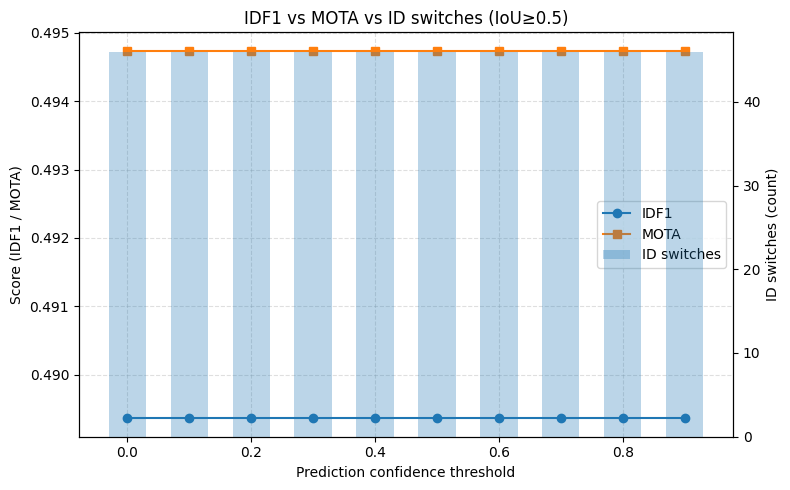

In [101]:
gt_file = r'Y:\ZHL\isds\PS\task0812\results\369\yolo_dataset_select_rename\mot_gt.csv'
pred_file = r'Y:\ZHL\isds\PS\task0812\results\369\yolo_dataset_select_rename\mot_pred.csv'
sweep_and_plot(gt_file, pred_file)

In [102]:
# -*- coding: utf-8 -*-
"""
MOT Visualization:
- 输入：GT 与 Pred 的 MOT 风格文件（frame,id,x,y,w,h,conf,class,visibility）
- 在图像上画：GT(绿色) / Pred(蓝色)，当帧匹配(连线)，ID Switch(红色描边)
- 输出：视频或逐帧图片
"""
import os
import glob
import math
import cv2
import numpy as np
import pandas as pd

try:
    from scipy.optimize import linear_sum_assignment
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

# ---------- 基础工具 ----------
def read_mot_like(path):
    cols = ['frame','id','x','y','w','h','conf','class','visibility']
    df = pd.read_csv(
        path, header=None, names=cols,
        sep=r'[,\s]+', engine='python',
        encoding='utf-8-sig', comment='#', skip_blank_lines=True
    )
    for k in cols:
        if k in df.columns:
            df[k] = pd.to_numeric(df[k], errors='coerce')
    df = df.dropna(subset=['frame','id','x','y','w','h'])
    df['frame'] = df['frame'].astype(np.int64)
    df['id']    = df['id'].astype(np.int64)
    return df.sort_values(['frame','id']).reset_index(drop=True)

def iou_matrix(a, b):
    """ a: Nx4, b:Mx4, box=(x,y,w,h) """
    if len(a)==0 or len(b)==0:
        return np.zeros((len(a), len(b)), dtype=float)
    a = a.astype(float); b = b.astype(float)
    ax1, ay1 = a[:,0], a[:,1]
    ax2, ay2 = a[:,0] + a[:,2], a[:,1] + a[:,3]
    bx1, by1 = b[:,0], b[:,1]
    bx2, by2 = b[:,0] + b[:,2], b[:,1] + b[:,3]

    inter_x1 = np.maximum(ax1[:,None], bx1[None,:])
    inter_y1 = np.maximum(ay1[:,None], by1[None,:])
    inter_x2 = np.minimum(ax2[:,None], bx2[None,:])
    inter_y2 = np.minimum(ay2[:,None], by2[None,:])

    inter_w = np.maximum(0.0, inter_x2 - inter_x1)
    inter_h = np.maximum(0.0, inter_y2 - inter_y1)
    inter = inter_w * inter_h

    area_a = (ax2-ax1) * (ay2-ay1)
    area_b = (bx2-bx1) * (by2-by1)
    union = area_a[:,None] + area_b[None,:] - inter
    iou = np.where(union>0, inter/union, 0.0)
    return iou

def match_by_iou(gt_boxes, pd_boxes, iou_thr=0.5):
    """返回匹配对 [(gi, pj)]，以及未匹配索引列表"""
    if len(gt_boxes)==0 or len(pd_boxes)==0:
        return [], list(range(len(gt_boxes))), list(range(len(pd_boxes)))
    ious = iou_matrix(gt_boxes, pd_boxes)

    # 匈牙利最大化 IoU（转成最小化cost）
    if HAS_SCIPY:
        cost = 1.0 - ious
        gi, pj = linear_sum_assignment(cost)
        pairs = []
        used_g, used_p = set(), set()
        for i, j in zip(gi, pj):
            if ious[i, j] >= iou_thr:
                pairs.append((i, j))
                used_g.add(i); used_p.add(j)
        unmatched_g = [i for i in range(len(gt_boxes)) if i not in used_g]
        unmatched_p = [j for j in range(len(pd_boxes)) if j not in used_p]
        return pairs, unmatched_g, unmatched_p
    else:
        # 无 scipy 时，贪心：每次选全局最大 IoU
        pairs = []
        used_g, used_p = set(), set()
        while True:
            i, j = np.unravel_index(np.argmax(ious), ious.shape)
            if ious[i, j] < iou_thr:
                break
            if i in used_g or j in used_p:
                ious[i, j] = -1  # 跳过
                continue
            pairs.append((i, j))
            used_g.add(i); used_p.add(j)
            ious[i, :] = -1
            ious[:, j] = -1
        unmatched_g = [x for x in range(len(gt_boxes)) if x not in used_g]
        unmatched_p = [y for y in range(len(pd_boxes)) if y not in used_p]
        return pairs, unmatched_g, unmatched_p

def draw_box(img, box, color, text=None, thick=2, is_switch=False):
    x,y,w,h = map(int, box)
    x2,y2 = x+w, y+h
    if is_switch:
        # 红色高亮边框（ID Switch）
        cv2.rectangle(img, (x-2,y-2), (x2+2,y2+2), (0,0,255), 3)
    cv2.rectangle(img, (x,y), (x2,y2), color, thick)
    if text:
        (tw, th), bl = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(img, (x, y- th - 6), (x + tw + 4, y), color, -1)
        cv2.putText(img, text, (x+2, y-4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2, cv2.LINE_AA)

# ---------- 图像加载 ----------
def collect_images(images_dir):
    exts = ('*.jpg','*.jpeg','*.png','*.bmp')
    files = []
    for e in exts:
        files += glob.glob(os.path.join(images_dir, e))
    files = sorted(files)
    return files

def frame_to_image_path(frame, images_dir, img_pattern=None, remap=None, files_cache=None):
    # 优先：pattern，如 "{:06d}.jpg"
    if img_pattern:
        path = os.path.join(images_dir, img_pattern.format(frame))
        return path if os.path.exists(path) else None
    # 其次：remap映射（将帧序号映射到排序后的文件）
    if remap is not None and 1 <= frame <= len(remap):
        return remap[frame-1]
    # 兜底：按名字排序后第 frame-1 张（要求从1开始连续）
    if files_cache and 1 <= frame <= len(files_cache):
        return files_cache[frame-1]
    return None

# ---------- 可视化主流程 ----------
def visualize_mot(
    gt_path, pred_path, images_dir,
    out_video_path=None, out_frames_dir=None,
    img_pattern=None,  # e.g. "{:06d}.jpg"
    iou_thr=0.5, fps=15, remap_frames_to_images=True
):
    # 读数据
    gt = read_mot_like(gt_path)
    pred = read_mot_like(pred_path)
    # 忽略区（常规做法：id<=0 不评估；若你的GT没有忽略区可注释掉）
    gt = gt[gt['id'] > 0]

    # 帧集合
    frames = sorted(set(gt['frame']).union(set(pred['frame'])))

    # 准备图像文件映射
    files_cache = collect_images(images_dir)
    if remap_frames_to_images:
        # 将排序后的帧号 1..N 映射到排序后的图片列表，便于你的帧号是时间戳时也能对上图
        # 注意：要求图片张数 >= 帧数，否则后面没有图可画
        if len(files_cache) < len(frames):
            print(f"[Warn] 图片数量({len(files_cache)}) < 帧数({len(frames)}), 末尾帧将无图。")
        frame2img_list = files_cache
    else:
        frame2img_list = None

    # 视频写出
    writer = None

    # 记录上一帧 GT->Pred 的配对，用于检测 ID Switch
    last_gt_to_pred = {}

    # 主循环
    for idx, f in enumerate(frames, 1):
        gtf = gt[gt['frame'] == f]
        prf = pred[pred['frame'] == f]

        # 取图
        img_path = frame_to_image_path(
            idx if remap_frames_to_images else f,
            images_dir,
            img_pattern=img_pattern,
            remap=frame2img_list,
            files_cache=files_cache
        )
        if img_path and os.path.exists(img_path):
            img = cv2.imread(img_path)
        else:
            # 没图时生成空白画布
            img = np.full((720, 1280, 3), 255, dtype=np.uint8)
            cv2.putText(img, f'No image for frame {f}', (30,60),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,0,255), 2)

        # 准备当帧数据
        gt_ids  = gtf['id'].to_numpy(dtype=int)
        pd_ids  = prf['id'].to_numpy(dtype=int)
        gt_box  = gtf[['x','y','w','h']].to_numpy(dtype=float)
        pd_box  = prf[['x','y','w','h']].to_numpy(dtype=float)

        # 匹配
        pairs, unmatched_g, unmatched_p = match_by_iou(gt_box, pd_box, iou_thr=iou_thr)

        # 先画 GT 与 Pred（基础颜色）
        # 标注 ID Switch：若某个 GT id 在上一帧匹配到的 Pred id 与本帧不同，则高亮
        switch_g = set()
        switch_p = set()

        # 计算本帧的 GT->Pred 映射（先默认，无开关信息）
        curr_map = {}

        for gi, pj in pairs:
            gid = gt_ids[gi]
            pid = pd_ids[pj]
            curr_map[gid] = pid
            if gid in last_gt_to_pred and last_gt_to_pred[gid] != pid:
                switch_g.add(gi)   # 该 GT box 高亮
                switch_p.add(pj)   # 对应 Pred 也高亮

        # 绘制 GT
        for i, gid in enumerate(gt_ids):
            is_sw = (i in switch_g)
            draw_box(img, gt_box[i], (0,200,0), text=f'GT:{gid}', thick=2, is_switch=is_sw)

        # 绘制 Pred
        for j, pid in enumerate(pd_ids):
            is_sw = (j in switch_p)
            draw_box(img, pd_box[j], (255,128,0), text=f'PD:{pid}', thick=2, is_switch=is_sw)

        # 画匹配连线（绿色）
        for gi, pj in pairs:
            gx = int(gt_box[gi][0] + gt_box[gi][2]/2)
            gy = int(gt_box[gi][1] + gt_box[gi][3]/2)
            px = int(pd_box[pj][0] + pd_box[pj][2]/2)
            py = int(pd_box[pj][1] + pd_box[pj][3]/2)
            cv2.line(img, (gx,gy), (px,py), (0,180,0), 2)

        # 信息栏
        h, w = img.shape[:2]
        panel_h = 36
        cv2.rectangle(img, (0,0), (w, panel_h), (30,30,30), -1)
        txt = f'Frame {f} | GT:{len(gtf)}  PD:{len(prf)}  Match:{len(pairs)}  IDSw:{len(switch_g)}'
        cv2.putText(img, txt, (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2, cv2.LINE_AA)

        # Legend
        cv2.rectangle(img, (w-360, 4), (w-10, 32), (30,30,30), -1)
        cv2.putText(img, 'GT=Green  Pred=Orange  Match=Line  ID-Switch=Red glow',
                    (w-350, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (240,240,240), 1, cv2.LINE_AA)

        # 写出帧
        if out_frames_dir:
            os.makedirs(out_frames_dir, exist_ok=True)
            cv2.imwrite(os.path.join(out_frames_dir, f'{idx:06d}.jpg'), img)

        # 写出视频
        if out_video_path:
            if writer is None:
                fourcc = cv2.VideoWriter_fourcc(*'mp4v')
                writer = cv2.VideoWriter(out_video_path, fourcc, fps, (w, h))
            writer.write(img)

        # 更新上一帧映射
        last_gt_to_pred = curr_map

    if writer is not None:
        writer.release()
    print('Done.')


In [104]:
GT_PATH = r'Y:\ZHL\isds\PS\task0812\results\369\yolo_dataset_select_rename\mot_gt.csv'
PRED_PATH = r'Y:\ZHL\isds\PS\task0812\results\369\yolo_dataset_select_rename\mot_pred.csv'
IMAGES_DIR= r'Y:\ZHL\isds\PS\task0812\results\369\yolo_dataset_select_rename\images'      # 里面放原始图像

# 可选：若你的图片是 000001.jpg 这类规则命名，建议给 pattern（效率更高）
# IMG_PATTERN = "{:06d}.jpg"
IMG_PATTERN = None

# 输出：视频或逐帧图片（都可）
OUT_VIDEO  = None        # 或 None
OUT_FRAMES = IMAGES_DIR+'_vis'                      # r'path\to\vis_frames'

visualize_mot(
    GT_PATH, PRED_PATH, IMAGES_DIR,
    out_video_path=OUT_VIDEO,
    out_frames_dir=OUT_FRAMES,
    img_pattern=IMG_PATTERN,
    iou_thr=0.5,
    fps=15,
    # 如果你的帧号是时间戳而图片是按文件名顺序排列（1..N），设 True
    # 若你的图片文件名就等于帧号（有 pattern），可设 False
    remap_frames_to_images=True
)


Done.
